# 第081课 异常检测与密度估计

训练只用正常参考；阈值只用干净校准。先手算，再看机制与真实负例。

In [1]:
import json, numpy as np
from pathlib import Path
from anomaly import *
from generate_data import make_data
from experiment import run
from IPython.display import display, Image
data=make_data()
print('种子:',data['seed'])
print('真实各集合大小:',{k:len(v['x']) for k,v in data['digits'].items()})

种子: 81021
真实各集合大小: {'train': 90, 'calibration': 45, 'normal_test': 43, 'anomaly_test': 181}


## 1 邻居半径与秩阈值手算

In [2]:
print('第二近邻距离:',KNNRadius(2).fit([[0],[2],[5]]).score([[1],[4]]))
c=calibrate([1,2,3,4,5],.34)
print('校准:',c,'分数4/5报警:',c.alarms([4,5]))
print('样本太少:',calibrate([1,2],.05))

第二近邻距离: [1. 2.]
校准: Calibration(threshold=4.0, rank=4, n=5, alpha=0.34, marginal_bound=0.3333333333333333) 分数4/5报警: [False  True]
样本太少: Calibration(threshold=inf, rank=3, n=2, alpha=0.05, marginal_bound=0.0)


## 2 冻结流程执行全部数据条件

gaussian FP 18 / 300 召回 0.5 分机制 {'bridge': 0.0, 'far': 1.0}
knn FP 20 / 300 召回 0.505 分机制 {'bridge': 0.01, 'far': 1.0}
lof FP 20 / 300 召回 0.995 分机制 {'bridge': 0.99, 'far': 1.0}
ocsvm FP 15 / 300 召回 0.525 分机制 {'bridge': 0.05, 'far': 1.0}


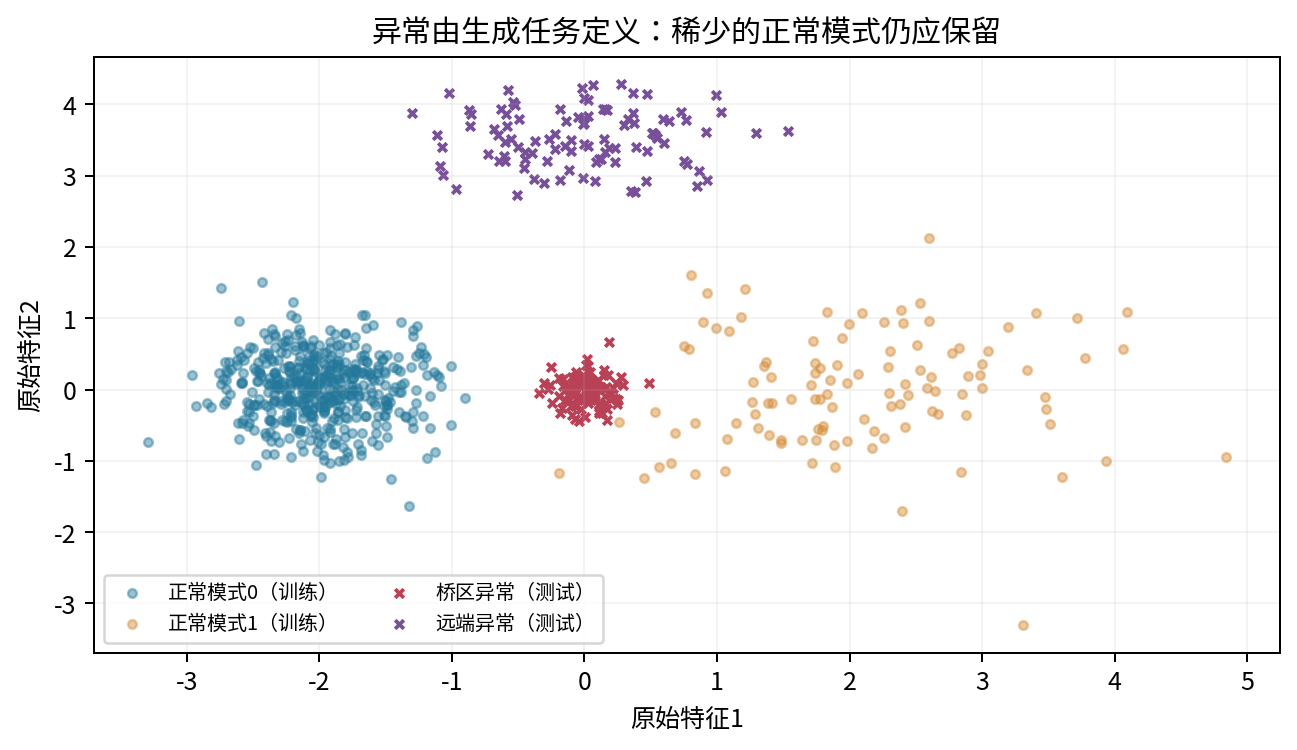

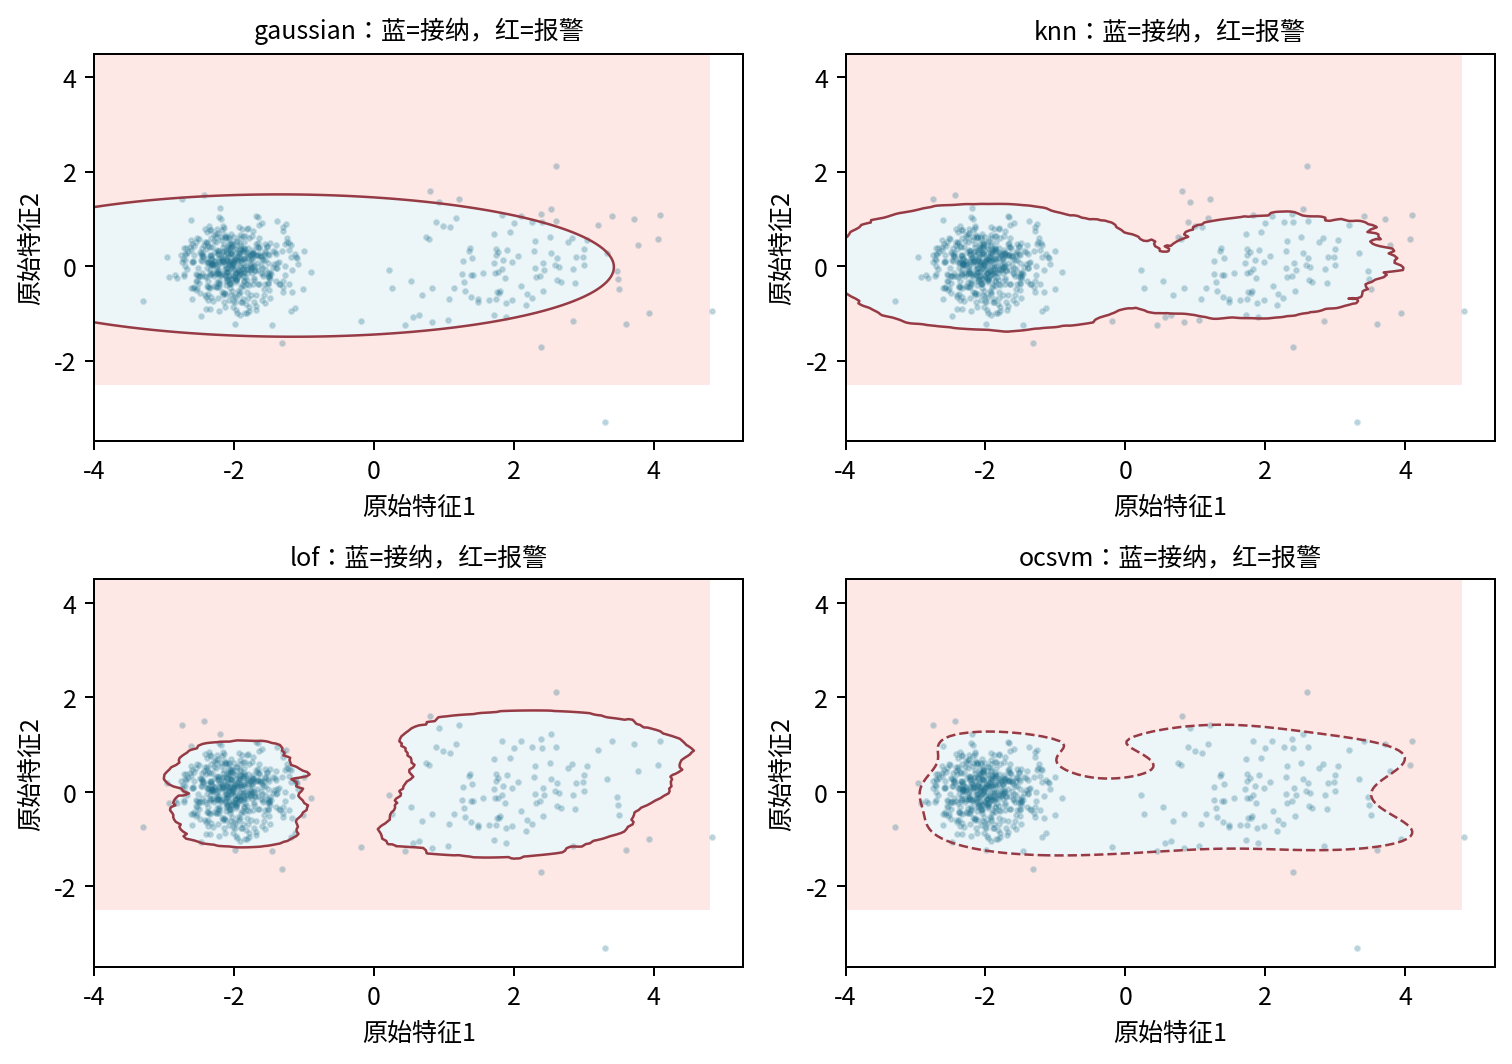

In [3]:
result,artifacts=run(True)
for method,row in result['synthetic']['methods'].items():
    print(method,'FP',row['false_positives'],'/',row['normal_n'],'召回',row['recall'],'分机制',row['recall_by_kind'])
display(Image(filename='figures/01_mechanisms.png'))
display(Image(filename='figures/02_boundaries.png'))

gaussian 阈值 5.777627149200491 边际界 0.05 正常子群 {'0': 0.0, '1': 0.3157894736842105}
knn 阈值 1.0143295294297492 边际界 0.05 正常子群 {'0': 0.00411522633744856, '1': 0.3333333333333333}
lof 阈值 1.4141089901181292 边际界 0.05 正常子群 {'0': 0.037037037037037035, '1': 0.19298245614035087}
ocsvm 阈值 -3.9233841135280505 边际界 0.05 正常子群 {'0': 0.01646090534979424, '1': 0.19298245614035087}
边际保证不是本次校准集的条件5%保证，也不是子群保证。


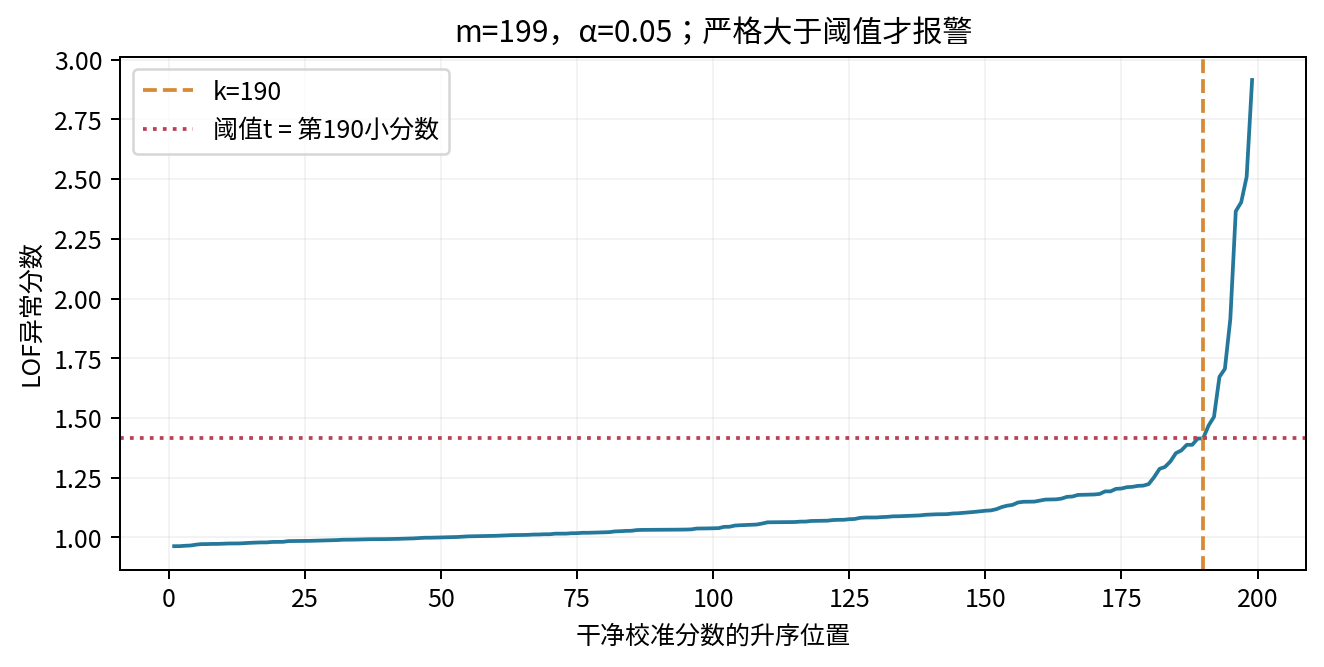

In [4]:
for method,row in result['synthetic']['methods'].items():
    print(method,'阈值',row['threshold'],'边际界',row['marginal_fpr_bound'],'正常子群',row['normal_group_fpr'])
display(Image(filename='figures/03_calibration.png'))
print('边际保证不是本次校准集的条件5%保证，也不是子群保证。')

情景推算真报警/误报/精确率: 9.0 499.5 0.017699115044247787


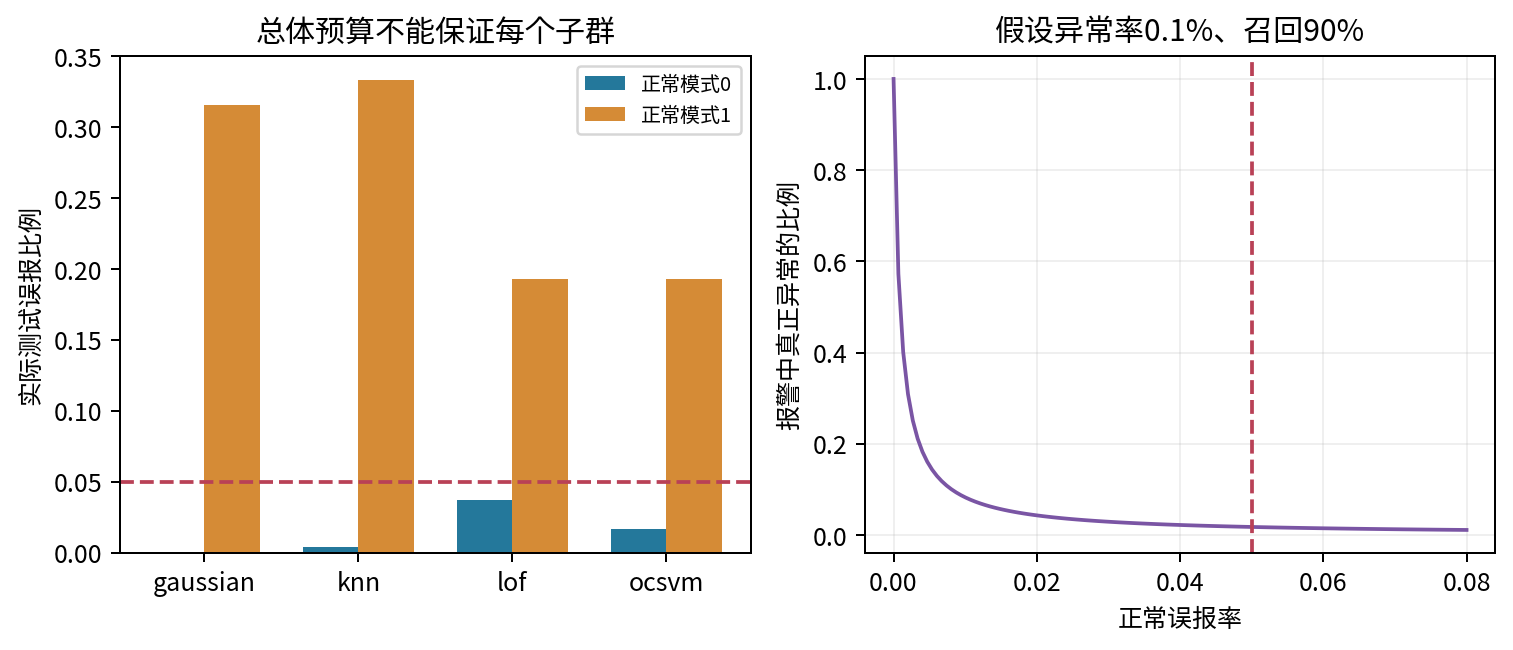

In [5]:
N,pi,fpr,recall=10000,.001,.05,.9
fp=N*(1-pi)*fpr;tp=N*pi*recall
print('情景推算真报警/误报/精确率:',tp,fp,tp/(tp+fp))
display(Image(filename='figures/04_budget.png'))

## 3 污染单独研究，真实负例不得删除

污染训练 gaussian 误报 0.06 召回 0.5
污染训练 knn 误报 0.06666666666666667 召回 0.5
污染训练 lof 误报 0.07 召回 0.54
污染训练 ocsvm 误报 0.06666666666666667 召回 0.505
真实Digits gaussian FP 2 / 43 区间 [0.012849260094380227, 0.15455498004063967] TP 181 / 181
真实Digits knn FP 1 / 43 区间 [0.004117087274333769, 0.12058993440607177] TP 181 / 181
真实Digits lof FP 0 / 43 区间 [0.0, 0.08200980322579117] TP 180 / 181
真实Digits ocsvm FP 0 / 43 区间 [0.0, 0.08200980322579117] TP 177 / 181


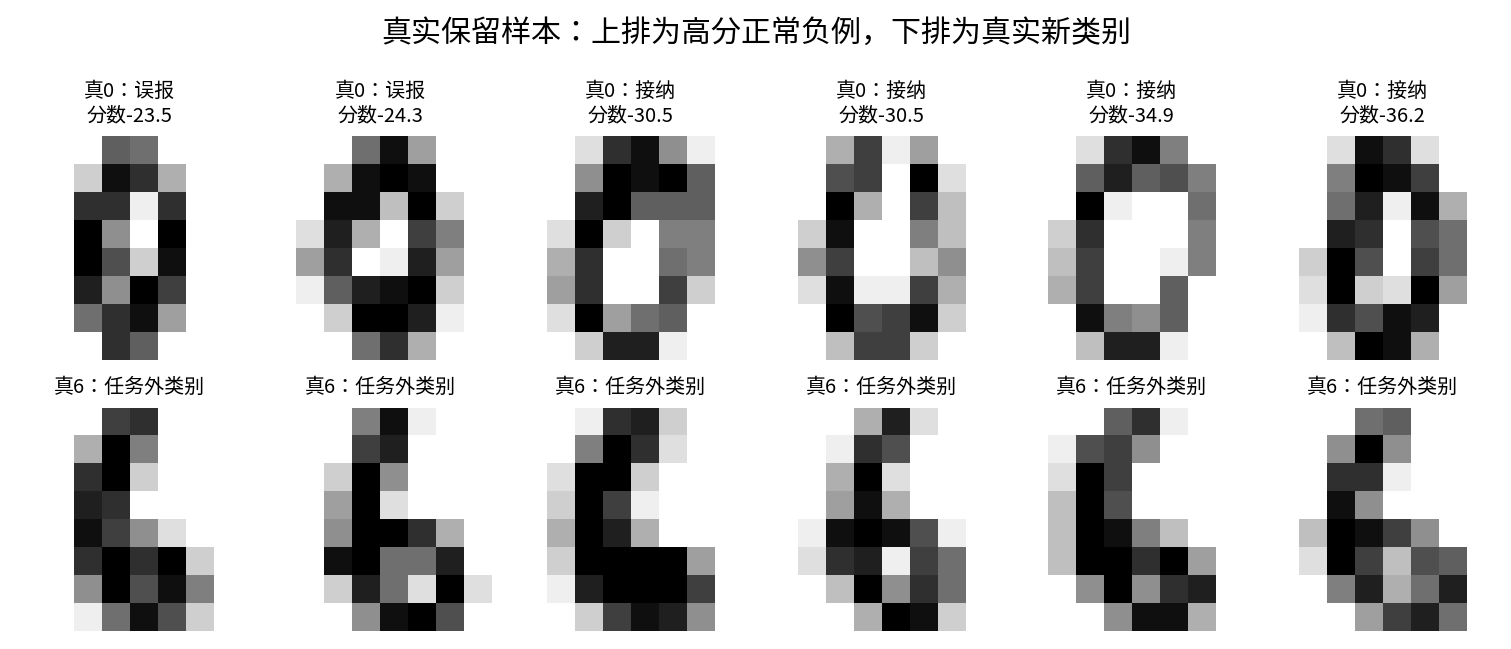

In [6]:
for method,row in result['contaminated_training']['methods'].items():
    print('污染训练',method,'误报',row['fpr'],'召回',row['recall'])
for method,row in result['digits']['methods'].items():
    print('真实Digits',method,'FP',row['false_positives'],'/',row['normal_n'],'区间',row['fpr_wilson95'],'TP',row['true_positives'],'/',row['anomaly_n'])
display(Image(filename='figures/05_real_negatives.png'))

In [7]:
try:
    calibrate([1,np.nan])
except ValueError as error:
    print('正确拒绝非法分数:',error)
else:
    raise RuntimeError('NaN was not rejected')

正确拒绝非法分数: scores must be a finite nonempty vector


In [8]:
import unittest
from test_experiment import Checks
checks=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromTestCase(Checks))
if not checks.wasSuccessful():
    raise RuntimeError('unit tests failed')
print('全部测试通过；真实部署与漂移未被本实验验证。')

全部测试通过；真实部署与漂移未被本实验验证。


...............
----------------------------------------------------------------------
Ran 15 tests in 0.170s

OK


## 复盘

高分不是有害概率；有限误报预算必须与基率、复核容量和正常子群一起解释。